# Rossmann_Sales_Forecasting

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit


In [ ]:
store = pd.read_csv("store.csv")
print(store.head())
print(store.describe())


   Store StoreType Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
0      1         c          a               1270.0                        9.0   
1      2         a          a                570.0                       11.0   
2      3         a          a              14130.0                       12.0   
3      4         c          c                620.0                        9.0   
4      5         a          a              29910.0                        4.0   

   CompetitionOpenSinceYear  Promo2  Promo2SinceWeek  Promo2SinceYear  \
0                    2008.0       0              NaN              NaN   
1                    2007.0       1             13.0           2010.0   
2                    2006.0       1             14.0           2011.0   
3                    2009.0       0              NaN              NaN   
4                    2015.0       0              NaN              NaN   

     PromoInterval  
0              NaN  
1  Jan,Apr,Jul,Oct  
2  Jan,Apr,

In [ ]:
train = pd.read_csv("train.csv")
train.describe()

/tmp/ipython-input-3767668564.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("/content/drive/My Drive/Data programming project/train.csv")


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
data = pd.merge(train, store, on='Store')
data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
data.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [ ]:
data.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [ ]:
filter = data.Open > 0

data_open = data[filter]

print(data_open.head())

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   
3              1         c          c                620.0   
4              1         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                   

In [ ]:
def add_time_features(df):
    """Add calendar-based features (Year, Month, Day, WeekOfYear)."""
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    return df

In [ ]:
flip = data_open.pivot_table(index='Store', columns='DayOfWeek', values='Sales', aggfunc=np.mean)
flip.head()

/tmp/ipython-input-693987898.py:1: FutureWarning: The provided callable <function mean at 0x797c3d978180> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  flip = data_open.pivot_table(index='Store', columns='DayOfWeek', values='Sales', aggfunc=np.mean)


DayOfWeek,1,2,3,4,5,6,7
Store,,,,,,,
1,5177.968750,4685.626866,4555.712121,4457.838710,4726.480620,4942.970149,NaN
2,6061.953125,5369.201493,5834.946970,4967.472441,4669.589147,2873.104478,NaN
3,8338.390625,7644.843284,7132.181818,6936.435484,7193.203125,4467.984962,NaN
4,10851.578125,9409.902985,8919.984848,9072.874016,9470.410853,10113.447761,NaN
5,6156.488189,5109.694030,5212.084615,4747.960317,4858.054688,2079.104478,NaN


In [ ]:
data_open['CompetitionDistance_Bin'] = pd.qcut(
        data_open['CompetitionDistance'],
        q=4,
        labels=['Very Near', 'Near', 'Medium', 'Far']
    )

data_open.head()


/tmp/ipython-input-3900327221.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_open['CompetitionDistance_Bin'] = pd.qcut(


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionDistance_Bin
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,Near
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",Very Near
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",Far
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,Very Near
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,Far


Text(0, 0.5, 'Sales')

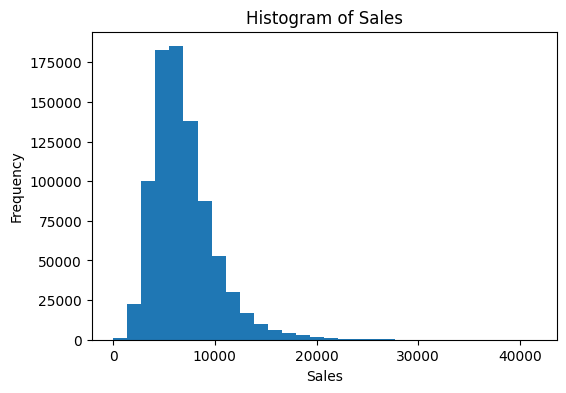

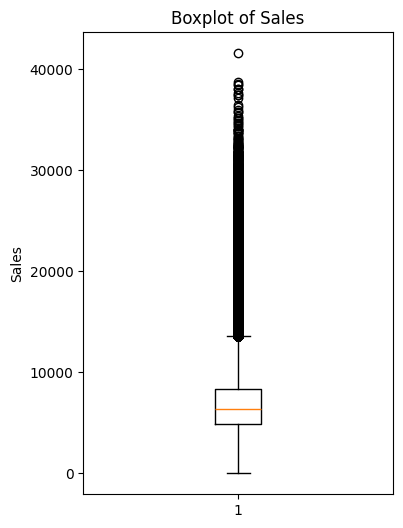

In [ ]:
# Histogram and Boxplot of Sales

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(data_open["Sales"].dropna(), bins=30)
ax.set_title(f"Histogram of {"Sales"}")
ax.set_xlabel("Sales")
ax.set_ylabel("Frequency")

fig, ax = plt.subplots(figsize=(4, 6))
ax.boxplot(data_open["Sales"].dropna(), vert=True)
ax.set_title(f"Boxplot of {"Sales"}")
ax.set_ylabel("Sales")

Text(0, 0.5, 'Customers')

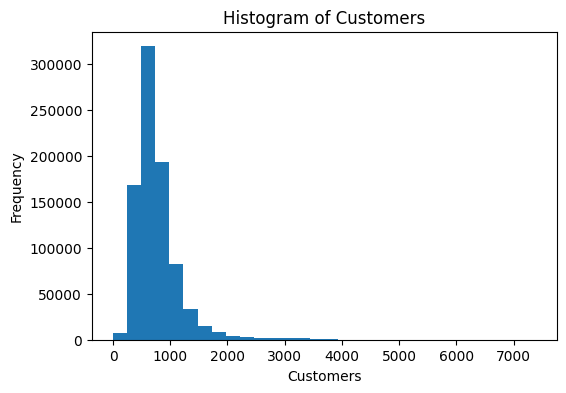

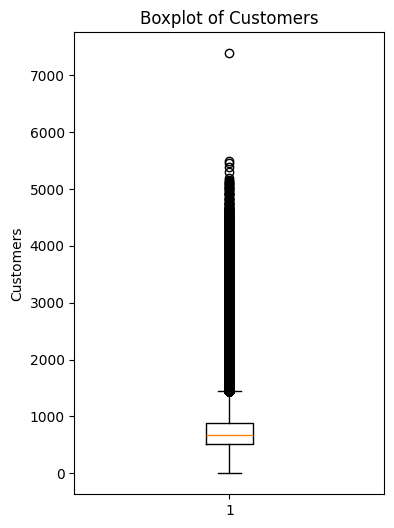

In [ ]:
# Histogram and Boxplot of Customers

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(data_open["Customers"].dropna(), bins=30)
ax.set_title(f"Histogram of {"Customers"}")
ax.set_xlabel("Customers")
ax.set_ylabel("Frequency")

fig, ax = plt.subplots(figsize=(4, 6))
ax.boxplot(data_open["Customers"].dropna(), vert=True)
ax.set_title(f"Boxplot of {"Customers"}")
ax.set_ylabel("Customers")

Text(0, 0.5, 'DayOfWeek')

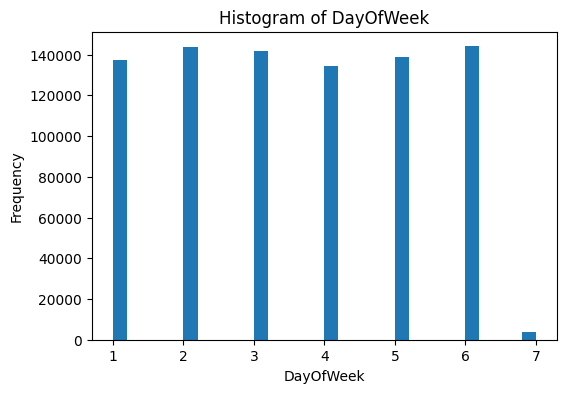

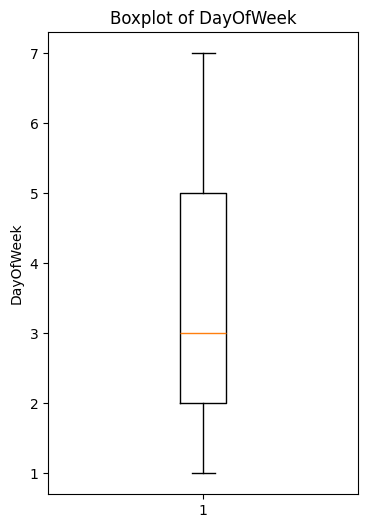

In [ ]:
# Histogram and Boxplot of DayOfWeek

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(data_open["DayOfWeek"].dropna(), bins=30)
ax.set_title(f"Histogram of {"DayOfWeek"}")
ax.set_xlabel("DayOfWeek")
ax.set_ylabel("Frequency")

fig, ax = plt.subplots(figsize=(4, 6))
ax.boxplot(data_open["DayOfWeek"].dropna(), vert=True)
ax.set_title(f"Boxplot of {"DayOfWeek"}")
ax.set_ylabel("DayOfWeek")

Text(0, 0.5, 'Frequency')

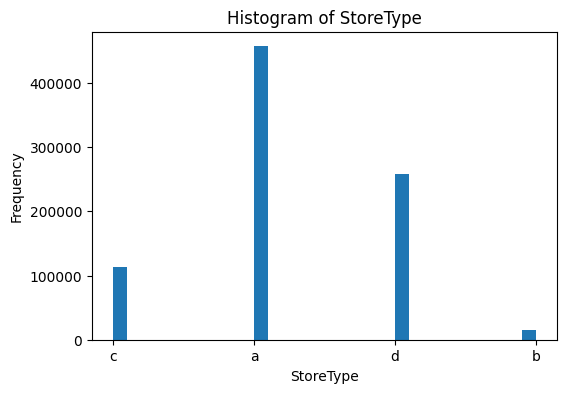

In [ ]:
# Histogram of StoreType

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(data_open["StoreType"].dropna(), bins=30)
ax.set_title(f"Histogram of {"StoreType"}")
ax.set_xlabel("StoreType")
ax.set_ylabel("Frequency")


Text(0, 0.5, 'Frequency')

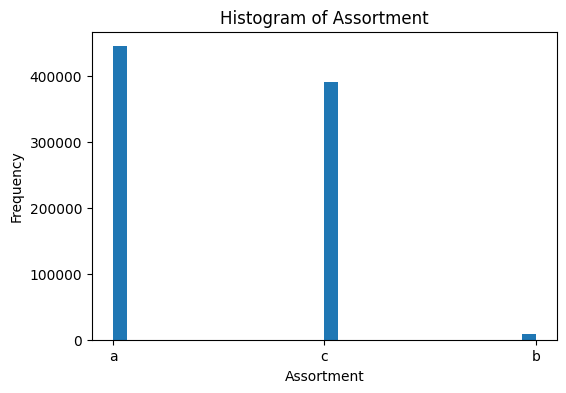

In [ ]:
# Histogram of Assortment

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(data_open["Assortment"].dropna(), bins=30)
ax.set_title(f"Histogram of {"Assortment"}")
ax.set_xlabel("Assortment")
ax.set_ylabel("Frequency")


Text(0, 0.5, 'CompetitionDistance')

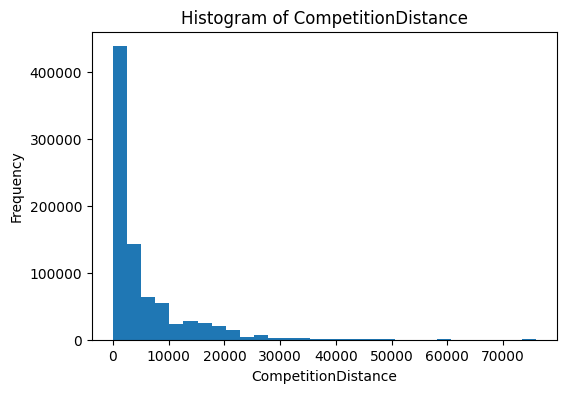

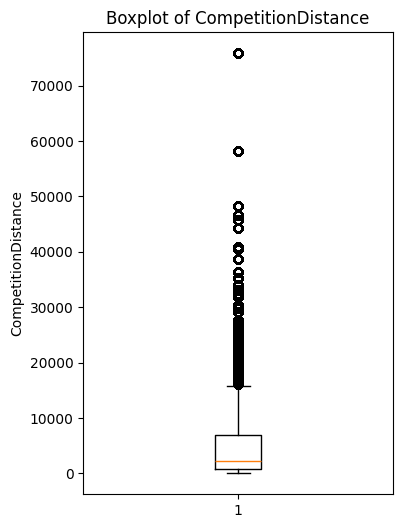

In [ ]:
# Histogram and Boxplot of CompetitionDistance

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(data_open["CompetitionDistance"].dropna(), bins=30)
ax.set_title(f"Histogram of {"CompetitionDistance"}")
ax.set_xlabel("CompetitionDistance")
ax.set_ylabel("Frequency")

fig, ax = plt.subplots(figsize=(4, 6))
ax.boxplot(data_open["CompetitionDistance"].dropna(), vert=True)
ax.set_title(f"Boxplot of {"CompetitionDistance"}")
ax.set_ylabel("CompetitionDistance")

<Axes: xlabel='Promo', ylabel='Sales'>

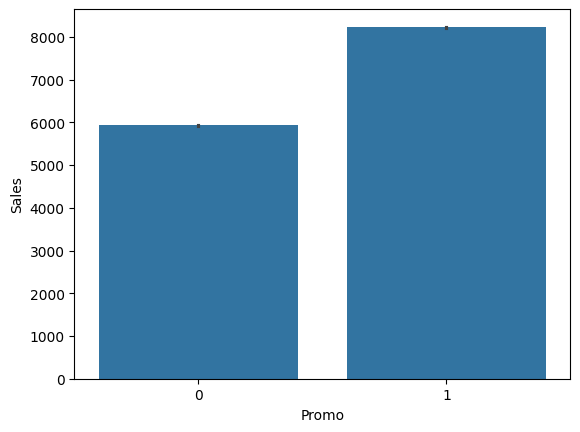

In [ ]:
# Sales by promotion status

sns.barplot(x='Promo', y='Sales', data=data_open)

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

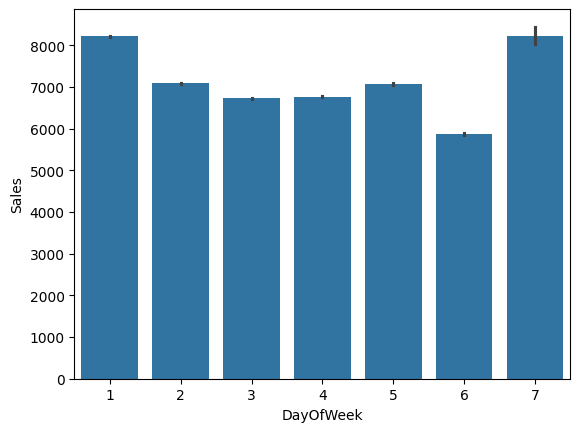

In [ ]:
# Sales by Day of Week

sns.barplot(x='DayOfWeek', y='Sales', data=data_open)

<Axes: xlabel='CompetitionDistance_Bin', ylabel='Sales'>

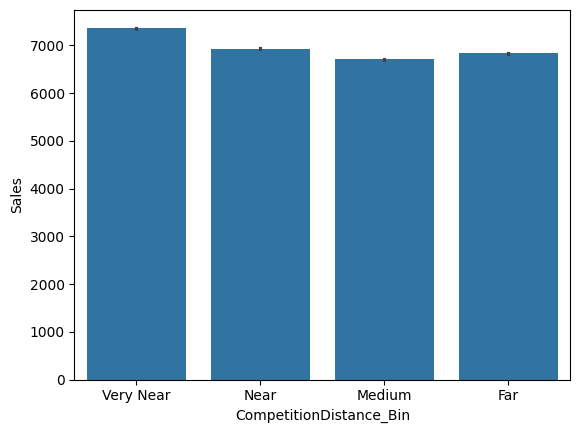

In [ ]:
# Sales by Competiton Distance

sns.barplot(x='CompetitionDistance_Bin', y='Sales', data=data_open)

Store type (a= regular store, b=larger store, c=small store, d=special or discount)

Assortment (a= basic/limited, b= extra/standard supermarket, c=extended/ big-city)


In [ ]:
count_store_type = data_open["StoreType"].value_counts()

print(count_store_type)

total_count = count_store_type.sum()

print(total_count)

StoreType
a    457077
d    258774
c    112978
b     15563
Name: count, dtype: int64
844392


In [ ]:
count_store_assortment = data_open["Assortment"].value_counts()

print(count_store_assortment)

Assortment
a    444909
c    391271
b      8212
Name: count, dtype: int64


In [ ]:
q1 = data_open["Sales"].quantile(0.25)
q3 = data_open["Sales"].quantile(0.75)


iqr_filter = (data_open["Sales"] >= q1) & (data_open["Sales"] <= q3)


iqr_count = iqr_filter.sum()


print(iqr_count)

422335


In [ ]:
data_regular = data_open[data_open["StoreType"] == "a"]
data_regular.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionDistance_Bin
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",Very Near
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",Far
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,Far
5,6,5,2015-07-31,5651,589,1,1,0,1,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN,Very Near
6,7,5,2015-07-31,15344,1414,1,1,0,1,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN,Far


In [ ]:
data_large = data_open[data_open["StoreType"] == "b"]
data_large.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionDistance_Bin
84,85,5,2015-07-31,7791,971,1,1,0,1,b,a,1870.0,10.0,2011.0,0,NaN,NaN,NaN,Near
258,259,5,2015-07-31,14096,2628,1,1,0,1,b,b,210.0,NaN,NaN,0,NaN,NaN,NaN,Very Near
261,262,5,2015-07-31,25774,3669,1,1,0,1,b,a,1180.0,5.0,2013.0,0,NaN,NaN,NaN,Near
273,274,5,2015-07-31,6975,1374,1,1,0,1,b,b,3640.0,NaN,NaN,1,10.0,2013.0,"Jan,Apr,Jul,Oct",Medium
334,335,5,2015-07-31,17867,2592,1,1,0,1,b,a,90.0,NaN,NaN,1,31.0,2013.0,"Jan,Apr,Jul,Oct",Very Near


In [ ]:
data_small = data_open[data_open["StoreType"] == "c"]
data_small.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionDistance_Bin
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,Near
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,Very Near
20,21,5,2015-07-31,9515,682,1,1,0,1,c,c,550.0,10.0,1999.0,1,45.0,2009.0,"Jan,Apr,Jul,Oct",Very Near
24,25,5,2015-07-31,14180,1586,1,1,0,1,c,a,430.0,4.0,2003.0,0,NaN,NaN,NaN,Very Near
33,34,5,2015-07-31,11144,1162,1,1,0,1,c,a,2240.0,9.0,2009.0,0,NaN,NaN,NaN,Near


In [ ]:
data_discount = data_open[data_open["StoreType"] == "d"]
data_discount.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionDistance_Bin
12,13,5,2015-07-31,8821,568,1,1,0,0,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov",Very Near
14,15,5,2015-07-31,9191,766,1,1,0,1,d,c,4110.0,3.0,2010.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",Medium
17,18,5,2015-07-31,10071,936,1,1,0,1,d,c,13840.0,6.0,2010.0,1,14.0,2012.0,"Jan,Apr,Jul,Oct",Far
19,20,5,2015-07-31,9593,974,1,1,0,0,d,a,2340.0,5.0,2009.0,1,40.0,2014.0,"Jan,Apr,Jul,Oct",Medium
22,23,5,2015-07-31,7273,560,1,1,0,1,d,a,4060.0,8.0,2005.0,0,NaN,NaN,NaN,Medium


/tmp/ipython-input-1092863549.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_open['Sales_Log'] = np.log1p(data_open['Sales'])


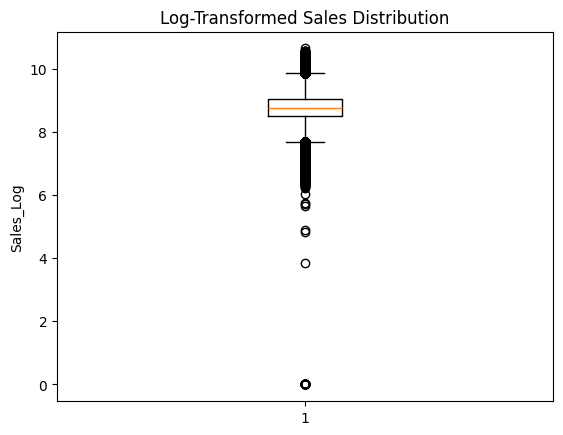

In [ ]:
# Log transformed Sales Boxplot

data_open['Sales_Log'] = np.log1p(data_open['Sales'])

fig, ax = plt.subplots()
ax.boxplot(data_open['Sales_Log'].dropna())
ax.set_title("Log-Transformed Sales Distribution")
ax.set_ylabel("Sales_Log")

fig.show()

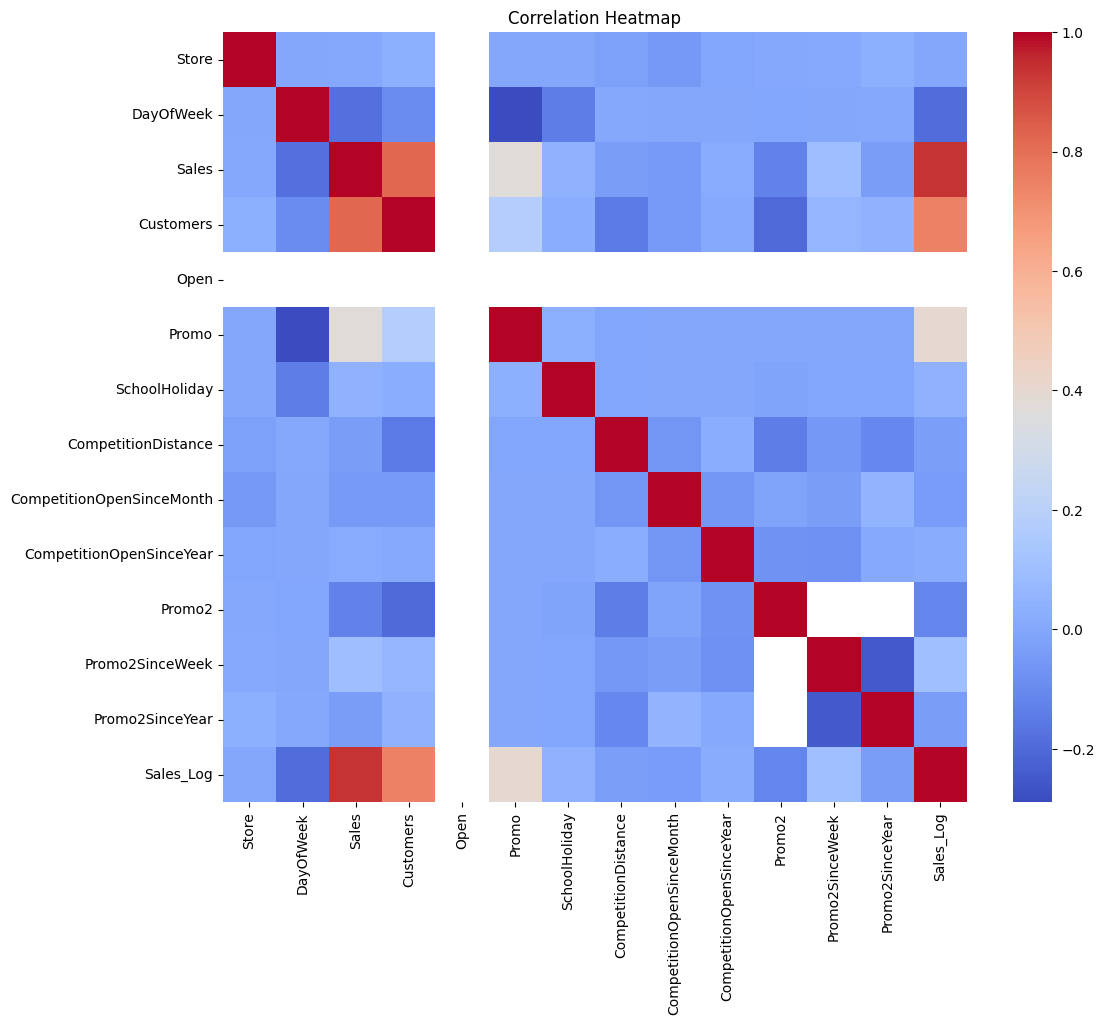

In [ ]:
# Correlation heatmap of features

num_df = data_open.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
sns.heatmap(num_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

<class 'pandas.core.frame.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   Store                      844392 non-null  int64   
 1   DayOfWeek                  844392 non-null  int64   
 2   Date                       844392 non-null  object  
 3   Sales                      844392 non-null  int64   
 4   Customers                  844392 non-null  int64   
 5   Open                       844392 non-null  int64   
 6   Promo                      844392 non-null  int64   
 7   StateHoliday               844392 non-null  object  
 8   SchoolHoliday              844392 non-null  int64   
 9   StoreType                  844392 non-null  object  
 10  Assortment                 844392 non-null  object  
 11  CompetitionDistance        842206 non-null  float64 
 12  CompetitionOpenSinceMonth  575773 non-null  float64 
 13  CompetitionOpenSin

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionDistance_Bin,Sales_Log
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,Near,8.568646
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",Very Near,8.710290
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",Far,9.025816
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,Very Near,9.546527
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,Far,8.481151


<function matplotlib.pyplot.show(close=None, block=None)>

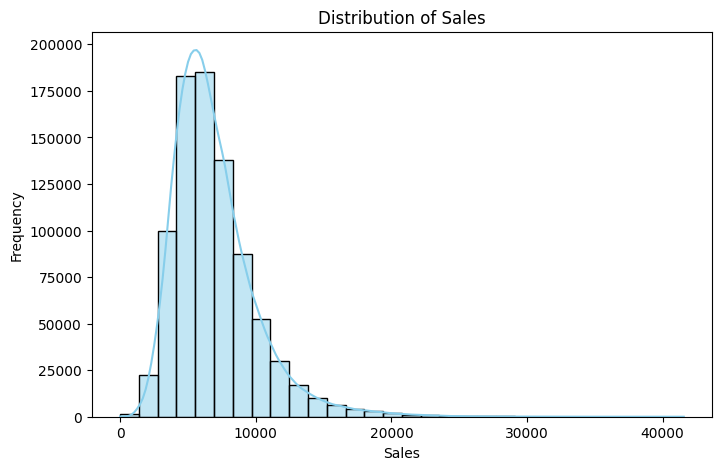

In [ ]:

print(data_open.info())
print(data_open.describe())

display(data_open.head())
plt.figure(figsize=(8,5))
sns.histplot(data_open['Sales'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


data = pd.merge(train, store, on="Store")

# Keep only open-store days
data_open = data[data["Open"] == 1].copy()


#  CONVERT DATE AND SORT

data_open["Date"] = pd.to_datetime(data_open["Date"])
data_open = data_open.sort_values(["Store", "Date"])


#  CREATE TIME-BASED FEATURES
data_open["Year"] = data_open["Date"].dt.year
data_open["Month"] = data_open["Date"].dt.month
data_open["Day"] = data_open["Date"].dt.day
data_open["WeekOfYear"] = data_open["Date"].dt.isocalendar().week.astype(int)


#  CREATE LAG FEATURES
data_open["Sales_Lag1"] = data_open.groupby("Store")["Sales"].shift(1)
data_open["Sales_Lag7"] = data_open.groupby("Store")["Sales"].shift(7)
data_open["Sales_Lag30"] = data_open.groupby("Store")["Sales"].shift(30)

# Rolling averages
data_open["Rolling_7"] = (
    data_open.groupby("Store")["Sales"].shift(1).rolling(7).mean()
)
data_open["Rolling_30"] = (
    data_open.groupby("Store")["Sales"].shift(1).rolling(30).mean()
)


#  DROP NA (lag-related)

data_model = data_open.dropna()


#  FEATURE SELECTION
features = [
    "Promo", "Customers", "CompetitionDistance",
    "Year", "Month", "Day", "WeekOfYear",
    "Sales_Lag1", "Sales_Lag7", "Sales_Lag30",
    "Rolling_7", "Rolling_30"
]

X = data_model[features]
y = data_model["Sales"]


# TRAIN/TEST SPLIT BASED ON DATE (TIME SERIES)
train_data = data_model[data_model["Date"] < "2015-01-01"]
test_data  = data_model[data_model["Date"] >= "2015-01-01"]

X_train = train_data[features]
y_train = train_data["Sales"]

X_test = test_data[features]
y_test = test_data["Sales"]


#  TRAIN RANDOM FOREST REGRESSOR
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=15, n_estimators=200, n_jobs=-1,
                      random_state=42)


--- Random Forest ---
MAE: 554.8753314561936
RMSE: 817.3069975830522
R²: 0.9035912030756842

--- Gradient Boosting ---
MAE: 609.2910713342178
RMSE: 861.0981638962555
R²: 0.892983299890726


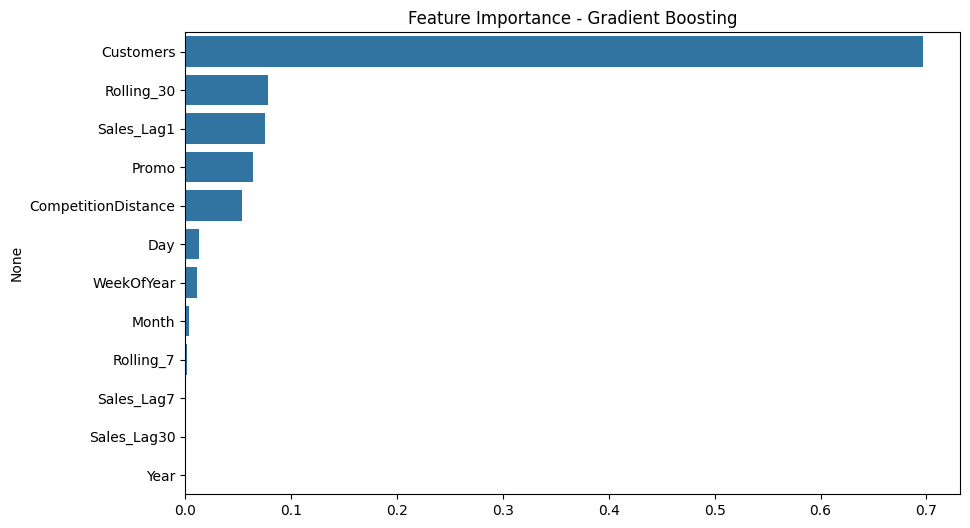

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

rf_pred = rf.predict(X_test)

# Train Gradient Boosting
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

#  Model Evaluation
def evaluate(model_name, y_true, y_pred):
    print(f"\n--- {model_name} ---")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²:", r2_score(y_true, y_pred))

evaluate("Random Forest", y_test, rf_pred)
evaluate("Gradient Boosting", y_test, gbr_pred)


#  Feature Importance (Gradient Boosting)
importances = pd.Series(gbr.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Gradient Boosting")
plt.show()


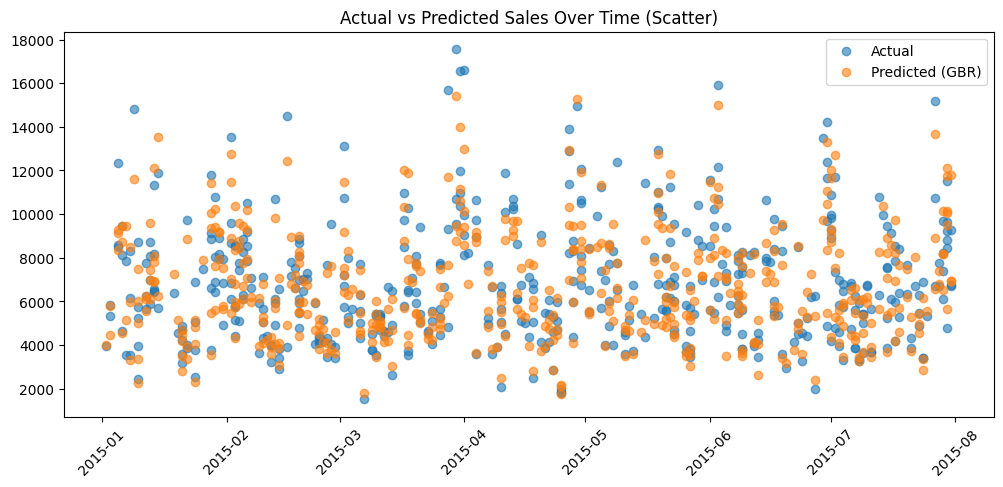

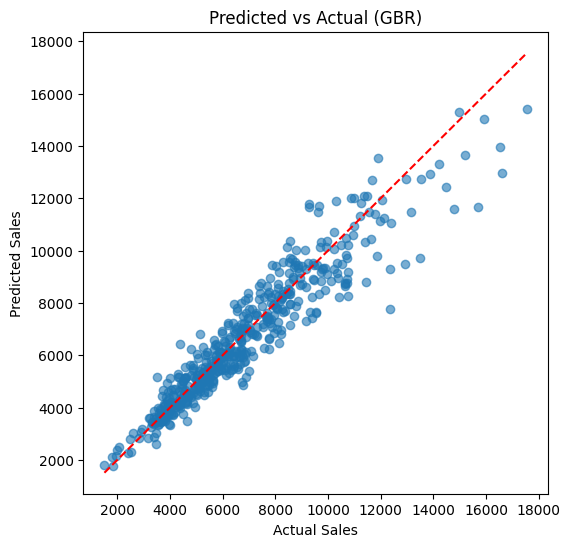

In [ ]:

# Sample data
sample = test_data.sample(500, random_state=42)
preds = gbr.predict(sample[features])

# Scatter plot of Actual vs Predicted over time
plt.figure(figsize=(12,5))
plt.scatter(sample['Date'], sample['Sales'], label='Actual', alpha=0.6)
plt.scatter(sample['Date'], preds, label='Predicted (GBR)', alpha=0.6)
plt.xticks(rotation=45)
plt.legend()
plt.title("Actual vs Predicted Sales Over Time (Scatter)")
plt.show()




actual = sample['Sales']

plt.figure(figsize=(6,6))
plt.scatter(actual, preds, alpha=0.6)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Predicted vs Actual (GBR)")

# Perfect prediction reference line
min_val = min(actual.min(), preds.min())
max_val = max(actual.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()

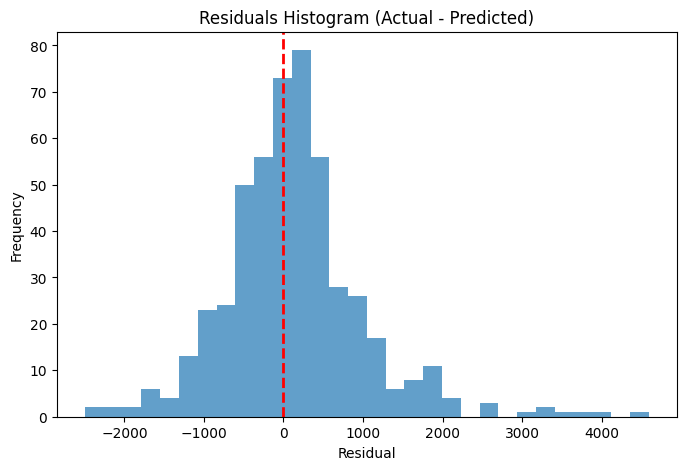

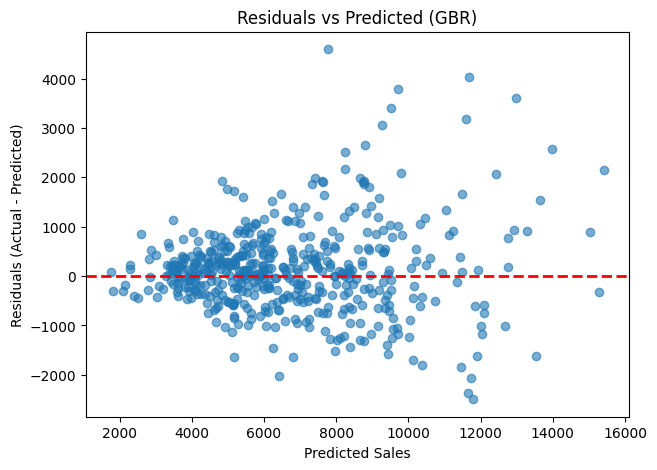

In [ ]:
# Compute residuals
residuals = actual - preds   # actual and preds already defined from earlier step

# Residuals histogram
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, alpha=0.7)
plt.title("Residuals Histogram (Actual - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.show()


# Residuals already computed:
# residuals = actual - preds

plt.figure(figsize=(7,5))
plt.scatter(preds, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted (GBR)")
plt.show()

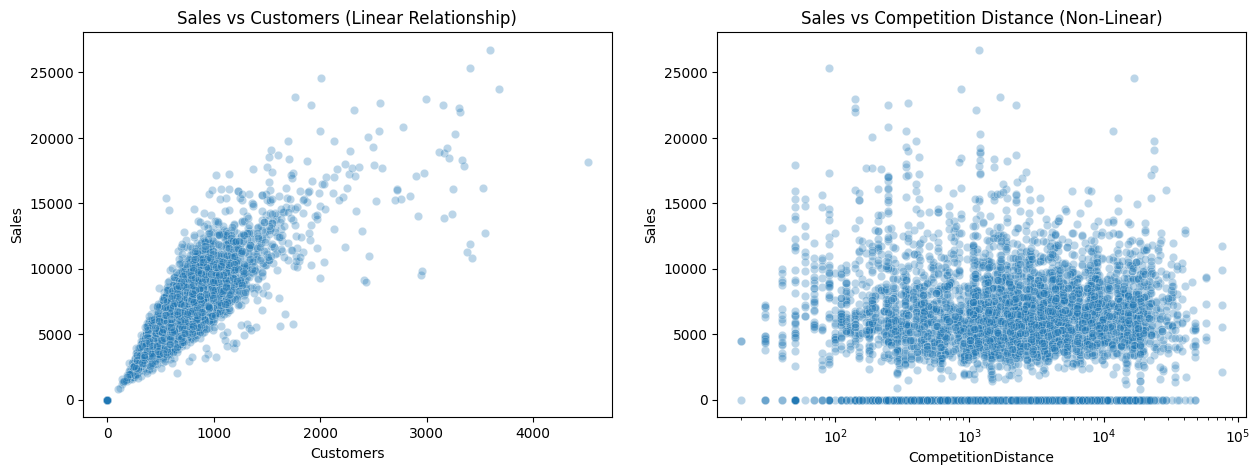

In [ ]:
# Sample for visualization to reduce rendering time
viz_sample = data.sample(5000, random_state=42)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Sales vs Customers (Often linear)
sns.scatterplot(x='Customers', y='Sales', data=viz_sample, ax=ax[0], alpha=0.3)
ax[0].set_title("Sales vs Customers (Linear Relationship)")

# Sales vs CompetitionDistance (Often non-linear)
sns.scatterplot(x='CompetitionDistance', y='Sales', data=viz_sample, ax=ax[1], alpha=0.3)
ax[1].set_xscale('log') # Log scale helps visualize the clumped data
ax[1].set_title("Sales vs Competition Distance (Non-Linear)")

plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Load Data
data = pd.merge(train, store, on="Store")
data = data[data["Open"] == 1].copy()
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(["Store", "Date"])

# HANDLING MISSING VALUES & INDICATORS
# Feedback applied: Instead of filling years with 0, we create binary indicators
data['Competition_Ind'] = np.where(data['CompetitionOpenSinceYear'].isna(), 0, 1)
data['Promo2_Ind'] = np.where(data['Promo2SinceYear'].isna(), 0, 1)

# Fill median for distance (as before) but fill others with median/mode for modeling purposes
# rather than 0 to avoid skewing the distribution for linear models
data['CompetitionDistance'].fillna(data['CompetitionDistance'].median(), inplace=True)
# Fill years with current mode or median just to satisfy model requirements,
# but the Model will rely on the Indicator columns created above.
data.fillna(0, inplace=True)


# FEATURE ENGINEERING
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
data["WeekOfYear"] = data["Date"].dt.isocalendar().week.astype(int)

# Log Transformation (Feedback: Mentioned in reflection but needed in code)
# We log transform Sales because the distribution is right-skewed
data['Sales_Log'] = np.log1p(data['Sales'])

# Create Lags (Dropping NAs immediately after to keep data clean)
data["Sales_Lag1"] = data.groupby("Store")["Sales"].shift(1)
data["Sales_Lag7"] = data.groupby("Store")["Sales"].shift(7)
data = data.dropna()

# Define Features
features = [
    "Promo", "Customers", "CompetitionDistance", "Competition_Ind", "Promo2_Ind",
    "Year", "Month", "Day", "WeekOfYear", "Sales_Lag1", "Sales_Lag7"
]



/tmp/ipython-input-1936352261.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['CompetitionDistance'].fillna(data['CompetitionDistance'].median(), inplace=True)


In [ ]:
# Train/Test Split (Chronological)
train_data = data[data["Date"] < "2015-06-01"]
test_data  = data[data["Date"] >= "2015-06-01"]

X_train = train_data[features]
y_train = train_data["Sales_Log"] # Predicting Log Sales
X_test = test_data[features]
y_test = test_data["Sales_Log"] # Predicting Log Sales

# --- 1. LINEAR REGRESSION (Baseline) --
# Feedback applied: Scaling data for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred_log = lr.predict(X_test_scaled)
lr_pred = np.expm1(lr_pred_log) # Inverse log for metrics

# --- 2. RANDOM FOREST (Set 1 Hyperparameters) ---
rf = RandomForestRegressor(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_pred_log = rf.predict(X_test)
rf_pred = np.expm1(rf_pred_log)

# --- 3. GRADIENT BOOSTING (Set 1: Learning Rate 0.1) ---
gbr1 = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gbr1.fit(X_train, y_train)
gbr1_pred_log = gbr1.predict(X_test)
gbr1_pred = np.expm1(gbr1_pred_log)

# --- 4. GRADIENT BOOSTING (Set 2: Lower LR, More Estimators) ---
gbr2 = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
gbr2.fit(X_train, y_train)
gbr2_pred_log = gbr2.predict(X_test)
gbr2_pred = np.expm1(gbr2_pred_log)

# Calculate True values for metrics
y_true = np.expm1(y_test)


In [ ]:
def get_metrics(y_true, y_pred, model_name, params):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": model_name, "Params": str(params), "MAE": mae, "RMSE": rmse, "R2": r2}

results = []
results.append(get_metrics(y_true, lr_pred, "Linear Regression", "Default (Scaled Data)"))
results.append(get_metrics(y_true, rf_pred, "Random Forest", "{n_est:100, depth:20}"))
results.append(get_metrics(y_true, gbr1_pred, "Gradient Boosting 1", "{n_est:200, lr:0.1, depth:5}"))
results.append(get_metrics(y_true, gbr2_pred, "Gradient Boosting 2", "{n_est:500, lr:0.05, depth:5}"))

results_df = pd.DataFrame(results)
print(results_df)


                 Model                         Params          MAE  \
0    Linear Regression          Default (Scaled Data)  1239.120352   
1        Random Forest          {n_est:100, depth:20}   568.135892   
2  Gradient Boosting 1   {n_est:200, lr:0.1, depth:5}   686.697830   
3  Gradient Boosting 2  {n_est:500, lr:0.05, depth:5}   666.873475   

          RMSE        R2  
0  2874.806101  0.146161  
1   840.545929  0.927007  
2  1010.139297  0.894580  
3   973.630994  0.902063  


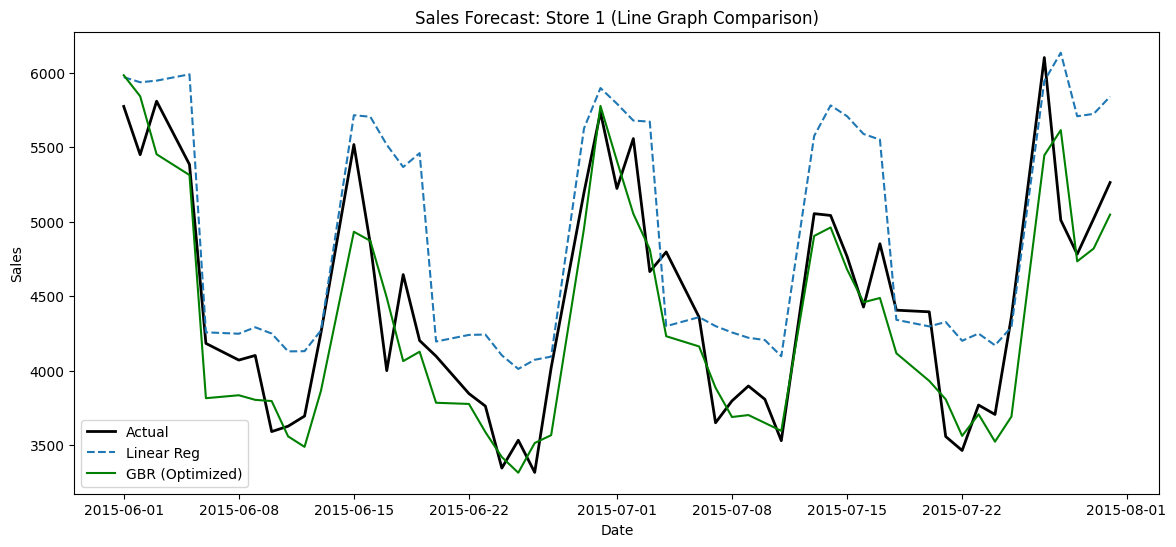

In [ ]:
# Plotting a sample single store for clarity
sample_store_id = test_data['Store'].iloc[0]
store_mask = test_data['Store'] == sample_store_id

plt.figure(figsize=(14, 6))
plt.plot(test_data[store_mask]['Date'], y_true[store_mask], label='Actual', color='black', linewidth=2)
plt.plot(test_data[store_mask]['Date'], lr_pred[store_mask], label='Linear Reg', linestyle='--')
plt.plot(test_data[store_mask]['Date'], gbr2_pred[store_mask], label='GBR (Optimized)', color='green')
plt.title(f"Sales Forecast: Store {sample_store_id} (Line Graph Comparison)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()



=== LinearRegression (Time-based split) RESULTS ===
MAE : 0.16
RMSE: 0.22
R²  : 0.7283


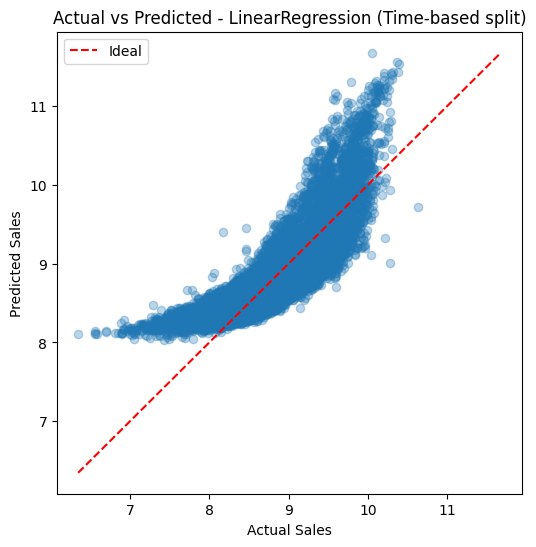

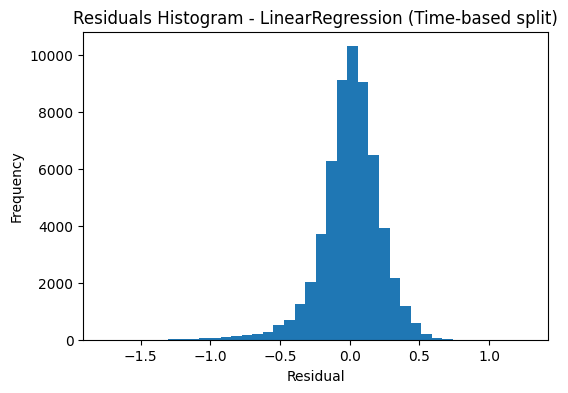


=== RandomForestRegressor RESULTS ===
MAE : 0.08
RMSE: 0.11
R²  : 0.9351


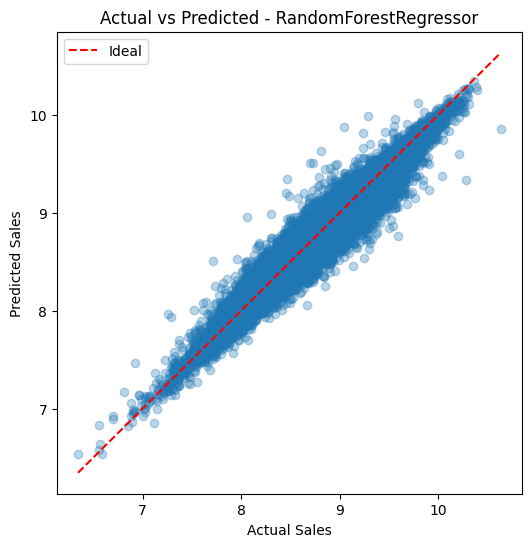

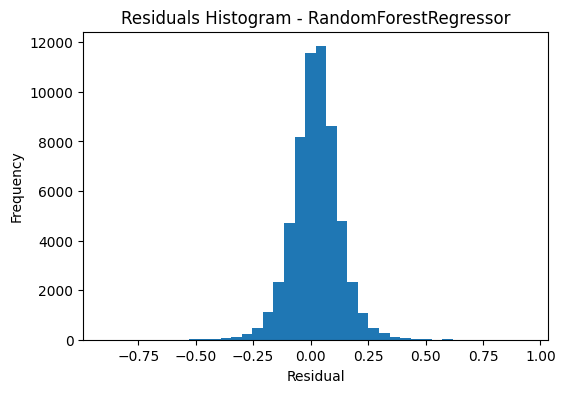


=== MODEL COMPARISON TABLE ===


,Model,MAE,RMSE,R2
0,LinearRegression (Time-based split),0.157786,0.216261,0.728282
1,RandomForestRegressor,0.079533,0.105667,0.935131


In [ ]:
# Linear Regression model added - Another evaluation method
# Uses the same X_train, X_test, y_train, y_test defined above.


# 1. Scale features for Linear Regression (helps with stability & interpretability)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Fit Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# 3. Predict on test set
y_pred_lr = lr.predict(X_test_scaled)

# 4. Evaluation function (mirrors Project 0.0.1 style)
def evaluate_and_plot(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {name} RESULTS ===")
    print(f"MAE : {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²  : {r2:,.4f}")

    # Actual vs Predicted scatter
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.3)
    line_min = min(y_true.min(), y_pred.min())
    line_max = max(y_true.max(), y_pred.max())
    ax.plot([line_min, line_max], [line_min, line_max], "r--", label="Ideal")
    ax.set_xlabel("Actual Sales")
    ax.set_ylabel("Predicted Sales")
    ax.set_title(f"Actual vs Predicted - {name}")
    ax.legend()
    plt.show()

    # Residuals histogram
    residuals = y_true - y_pred
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(residuals, bins=40)
    ax.set_title(f"Residuals Histogram - {name}")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    plt.show()

    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

# 5. Evaluate Linear Regression
results_lr = evaluate_and_plot("LinearRegression (Time-based split)", y_test, y_pred_lr)

# 6. Evaluate the Random Forest using the same helper

y_pred_rf = rf.predict(X_test)
results_rf = evaluate_and_plot("RandomForestRegressor", y_test, y_pred_rf)

# 7. Compare in a small DataFrame
results_df = pd.DataFrame([results_lr, results_rf])
print("\n=== MODEL COMPARISON TABLE ===")
display(results_df)

# Gradient Boosting Regressor (GBR) Added
from sklearn.ensemble import GradientBoostingRegressor

# 1. Train Gradient Boosting model - increasing estimators and reducing learning rate
gbr = GradientBoostingRegressor(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=4,
    random_state=42
)
gbr.fit(X_train, y_train)

# 2. Predict
y_pred_gbr = gbr.predict(X_test)

# 3. Evaluate using the same helper function
results_gbr = evaluate_and_plot("GradientBoostingRegressor", y_test, y_pred_gbr)

# 4. Append to results DataFrame
results_df = pd.DataFrame([results_lr, results_rf, results_gbr])
print("\n=== MODEL COMPARISON TABLE (LR vs RF vs GBR) ===")
display(results_df)


=== LinearRegression (Time-based split) RESULTS ===
MAE : 0.16
RMSE: 0.22
R²  : 0.7283


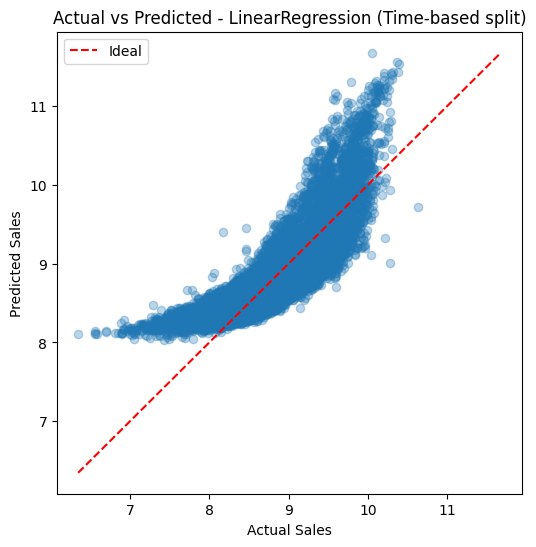

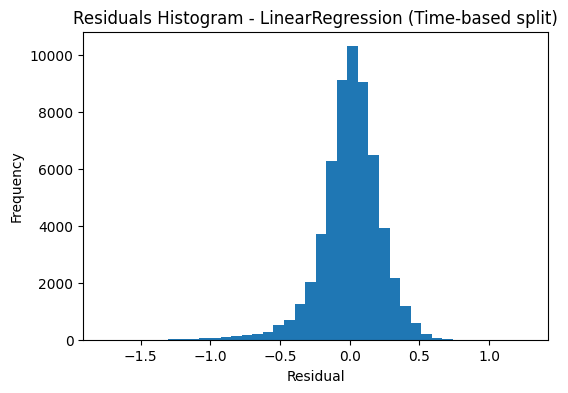


=== RandomForestRegressor RESULTS ===
MAE : 0.08
RMSE: 0.11
R²  : 0.9351


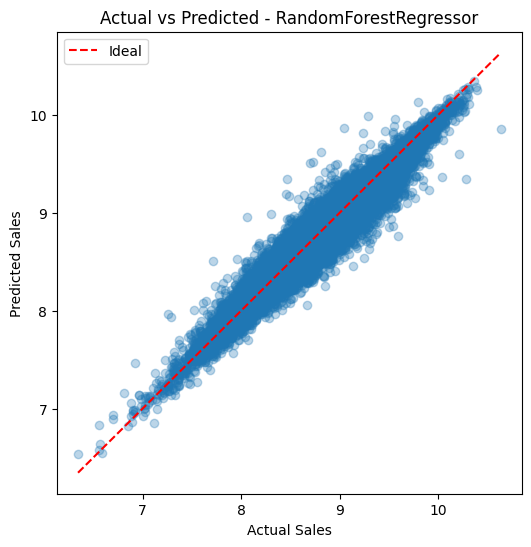

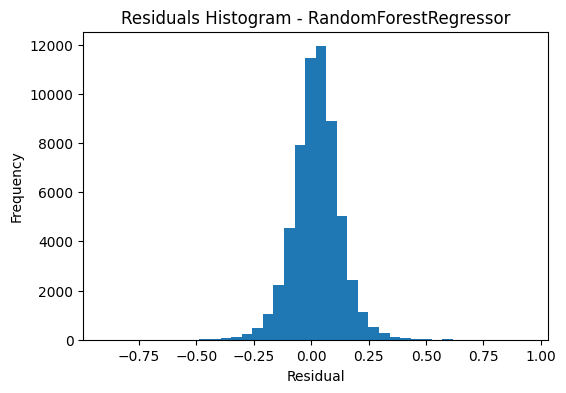


=== MODEL COMPARISON TABLE ===


,Model,MAE,RMSE,R2
0,LinearRegression (Time-based split),0.157786,0.216261,0.728282
1,RandomForestRegressor,0.079530,0.105668,0.935130



=== GradientBoostingRegressor RESULTS ===
MAE : 0.10
RMSE: 0.13
R²  : 0.9012


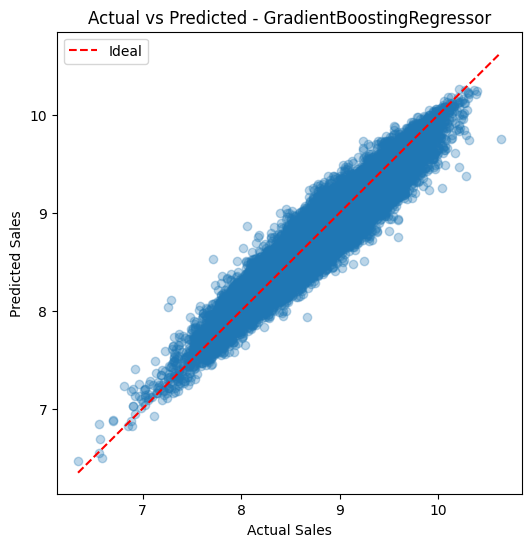

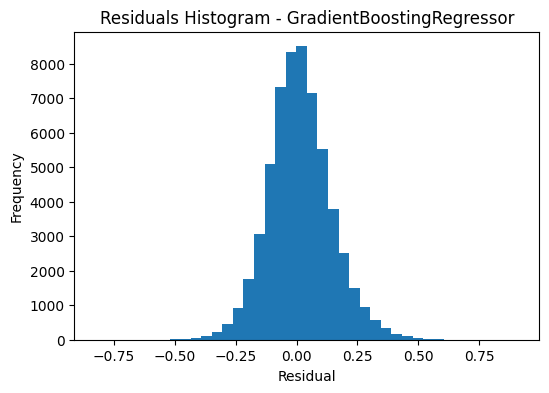


=== MODEL COMPARISON TABLE (LR vs RF vs GBR) ===


,Model,MAE,RMSE,R2
0,LinearRegression (Time-based split),0.157786,0.216261,0.728282
1,RandomForestRegressor,0.079530,0.105668,0.935130
2,GradientBoostingRegressor,0.100243,0.130373,0.901250


In [ ]:

#-----------------WITH LAGGING FEATURES -----------------------------#



def add_time_features(df):
    #add calendar-based features (Year, Month, Day, WeekOfYear).
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    return df


def add_lag_and_rolling(df):
    """
    Add lag features and rolling averages per Store.
    Assumes df has 'Store' and 'Sales' columns and is already date-sorted.
    """
    df = df.copy()
    df = df.sort_values(['Store', 'Date'])

    # Lags
    df['Sales_Lag1'] = df.groupby('Store')['Sales'].shift(1)
    df['Sales_Lag7'] = df.groupby('Store')['Sales'].shift(7)
    df['Sales_Lag30'] = df.groupby('Store')['Sales'].shift(30)

    # Rolling averages (requires min periods so we don't average tiny windows)
    df['Rolling_7'] = (
        df.groupby('Store')['Sales']
        .shift(1)  # avoid peeking at current day
        .rolling(window=7, min_periods=3)
        .mean()
    )
    df['Rolling_30'] = (
        df.groupby('Store')['Sales']
        .shift(1)
        .rolling(window=30, min_periods=10)
        .mean()
    )

    # Drop rows where we don't have full lag/rolling history
    df = df.dropna(subset=['Sales_Lag1', 'Sales_Lag7', 'Sales_Lag30',
                           'Rolling_7', 'Rolling_30'])
    return df


def evaluate_and_plot(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {name} RESULTS ===")
    print(f"MAE : {mae:,.4f}")
    print(f"RMSE: {rmse:,.4f}")
    print(f"R²  : {r2:,.4f}")

    # Actual vs Predicted scatter
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.3)
    line_min = min(y_true.min(), y_pred.min())
    line_max = max(y_true.max(), y_pred.max())
    ax.plot([line_min, line_max], [line_min, line_max], "r--", label="Ideal")
    ax.set_xlabel("Actual Sales")
    ax.set_ylabel("Predicted Sales")
    ax.set_title(f"Actual vs Predicted - {name}")
    ax.legend()
    plt.show()

    # Residuals histogram
    residuals = y_true - y_pred
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(residuals, bins=40)
    ax.set_title(f"Residuals Histogram - {name}")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    plt.show()

    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}


def run_model_comparison(df):

    #Full pipeline:
      # - add time, lag, and rolling features
      # - time-based split
      # - fit LR, RF, GBR
      # - return comparison table + feature-engineered df + models

    # 1) Add features
    df_fe = add_time_features(df)
    df_fe = add_lag_and_rolling(df_fe)

    # 2) Define feature set (includes lag + rolling)
    feature_cols = [
        'Customers',
        'Promo',
        'CompetitionDistance',
        'Year', 'Month', 'Day', 'WeekOfYear',
        'Sales_Lag1', 'Sales_Lag7', 'Sales_Lag30',
        'Rolling_7', 'Rolling_30'
    ]

    # 3) Train/test split by time (no leakage)
    cutoff_date = pd.to_datetime("2015-01-01")
    train_mask = df_fe['Date'] < cutoff_date

    X_train = df_fe.loc[train_mask, feature_cols]
    y_train = df_fe.loc[train_mask, 'Sales']

    X_test = df_fe.loc[~train_mask, feature_cols]
    y_test = df_fe.loc[~train_mask, 'Sales']

    # 4) Linear Regression (with scaling)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    y_pred_lr = lr.predict(X_test_scaled)
    results_lr = evaluate_and_plot("LinearRegression (Time-based split)", y_test, y_pred_lr)

    # 5) Random Forest
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    results_rf = evaluate_and_plot("RandomForestRegressor", y_test, y_pred_rf)

    # 6) Gradient Boosting
    gbr = GradientBoostingRegressor(
        n_estimators=1200,
        learning_rate=0.02,
        max_depth=4,
        random_state=42
    )
    gbr.fit(X_train, y_train)
    y_pred_gbr = gbr.predict(X_test)
    results_gbr = evaluate_and_plot("GradientBoostingRegressor", y_test, y_pred_gbr)

    # 7) Comparison table
    results_df = pd.DataFrame([results_lr, results_rf, results_gbr])
    print("\n=== MODEL COMPARISON TABLE (LR vs RF vs GBR) ===")
    display(results_df)

    models = {"lr": lr, "rf": rf, "gbr": gbr, "scaler": scaler}
    return results_df, df_fe, models

# results_df, df_fe, models = run_model_comparison(df)